In [1]:
import cv2
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, ConfusionMatrixDisplay
import os

In [2]:
IMG_SIZE = (227, 227)
INPUT_SHAPE = (227, 227, 3)
# LABELS = np.array(['Bacterialblight', 'Blast', 'Brownspot', 'Healthy', 'Tungro'])
# LABELS = np.array(['Hispa', 'LeafBlast', 'BrownSpot', 'Healthy'])
dataset_path = 'datasets/local_dataset_no_duplicate'
# augmented_dataset_path = 'datasets/Mixed on field/augmented_images'
is_train_splitted = False
LABELS = np.array(os.listdir(f'{dataset_path}/train_images')) if is_train_splitted else np.array(os.listdir(dataset_path))
TRAIN_SPLIT_RATIO = 0.8
# TEST_SPLIT_RATIO = 0.5
BUFFER_SIZE = tf.data.AUTOTUNE
BATCH_SIZE = 32
N_SPLITS = 5

RESULT_PATH = 'Results/250826 2156 Mixed On Field No Duplicate Normal Indo'
EXTRACTOR_PATH = os.path.join(RESULT_PATH, 'mobilenet_feature_extractor.h5')
SCALER_PATH = os.path.join(RESULT_PATH, 'scaler.pkl')
SVM_MODEL_PATH = os.path.join(RESULT_PATH, 'svm_model.pkl')

In [3]:
def show_class_distribution(labels, title="Class Distribution"):
    """Menampilkan distribusi kelas dalam data label."""
    class_counts = {class_name: labels.count(class_name) for class_name in LABELS}
    
    # Mempersiapkan data untuk plot
    counts = [class_counts[name] for name in LABELS]
    
    # Menampilkan plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(LABELS, counts, color='blue')
    
    # Menambahkan angka di atas setiap batang
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')
        
    plt.title(title, fontsize=16)
    plt.xlabel("Nama Kelas", fontsize=12)
    plt.ylabel("Jumlah Gambar", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

In [4]:
# Load data
def load_images_from_directory(base_path, limit=1000):
    data = []
    labels = []
    for folder_name in LABELS:
        data_length = len(data)
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue
        
        print(len(os.listdir(folder_path)), "images in", folder_name)
        for i, filename in enumerate(os.listdir(folder_path)):
            if i == limit: break
            image_path = os.path.join(folder_path, filename)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image: {image_path}")
                continue

            data.append(cv2.resize(img, IMG_SIZE))
            labels.append(folder_name)
        print(f"Loaded {len(data)-data_length} images from {folder_name}")
    print('dataset loaded')
    print('dataset len:', len(data))
    print('labels len:', len(labels))
    show_class_distribution(labels, title=base_path)
    return np.array(data), np.array(labels)


1326 images in bacterial_leaf_blight
Loaded 1326 images from bacterial_leaf_blight
960 images in blast
Loaded 960 images from blast
1200 images in brown_spot
Loaded 1200 images from brown_spot
0 images in normal
Loaded 0 images from normal
1308 images in tungro
Loaded 1308 images from tungro
dataset loaded
dataset len: 4794
labels len: 4794


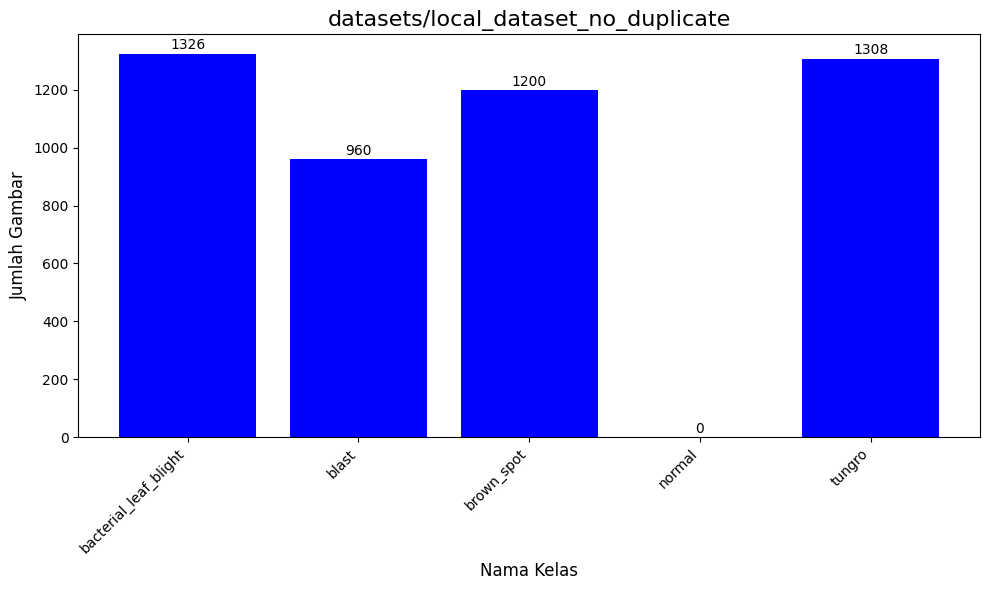

In [5]:
dataset, labels = load_images_from_directory(dataset_path, 1400)

80 images in bacterial_leaf_blight
Loaded 80 images from bacterial_leaf_blight
80 images in blast
Loaded 80 images from blast
Directory not found: datasets/leaf-rice-disease-indonesia\brown_spot
Directory not found: datasets/leaf-rice-disease-indonesia\normal
80 images in tungro
Loaded 80 images from tungro
dataset loaded
dataset len: 240
labels len: 240
180 images in bacterial_leaf_blight
Loaded 180 images from bacterial_leaf_blight
305 images in blast
Loaded 305 images from blast
267 images in brown_spot
Loaded 267 images from brown_spot
157 images in normal
Loaded 157 images from normal
Directory not found: datasets/rice_leaves_disease\tungro
dataset loaded
dataset len: 909
labels len: 909
extra dataset loaded
dataset shape: (5943, 227, 227, 3)
labels shape: (5943,)


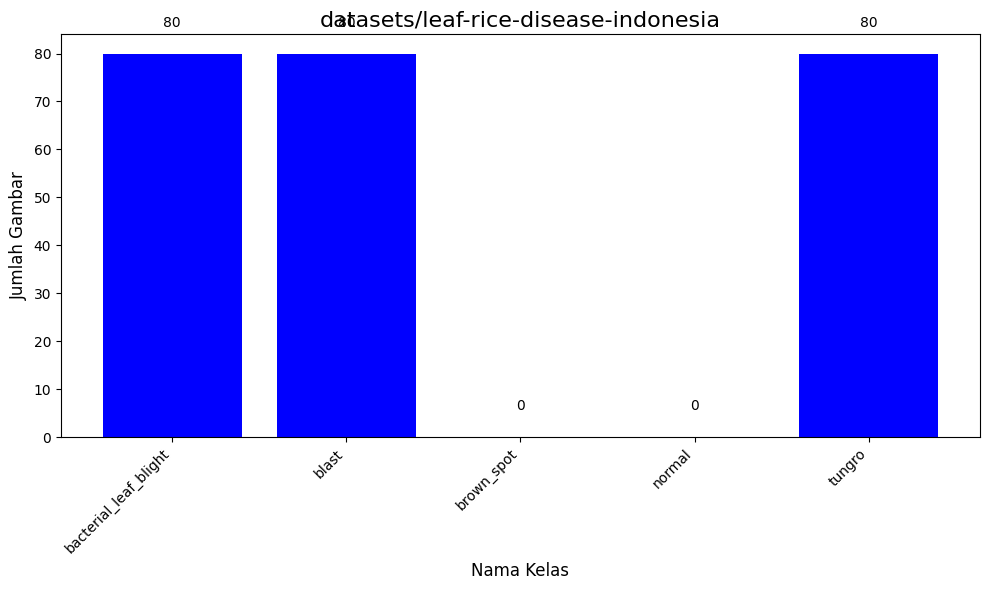

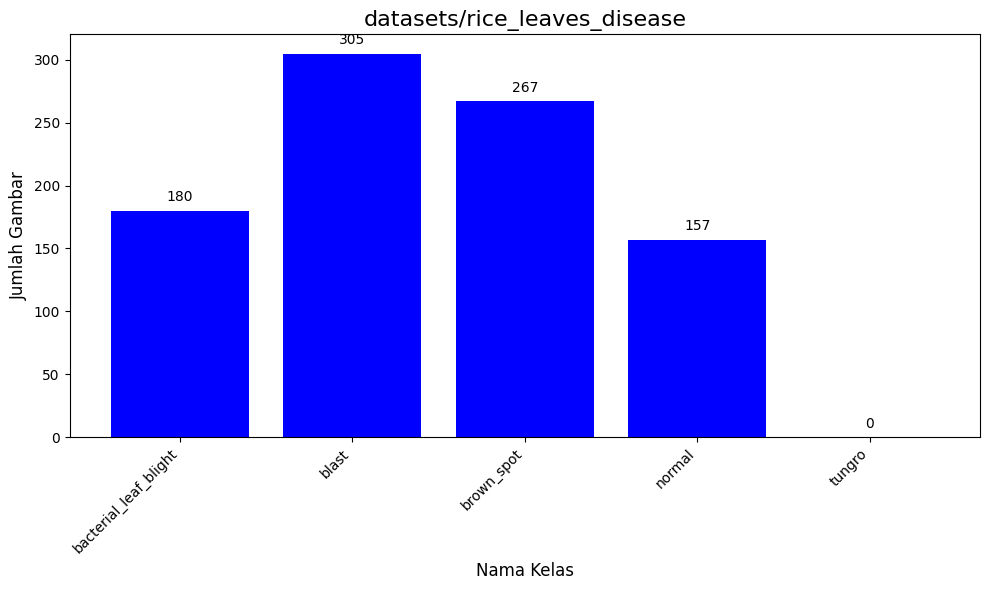

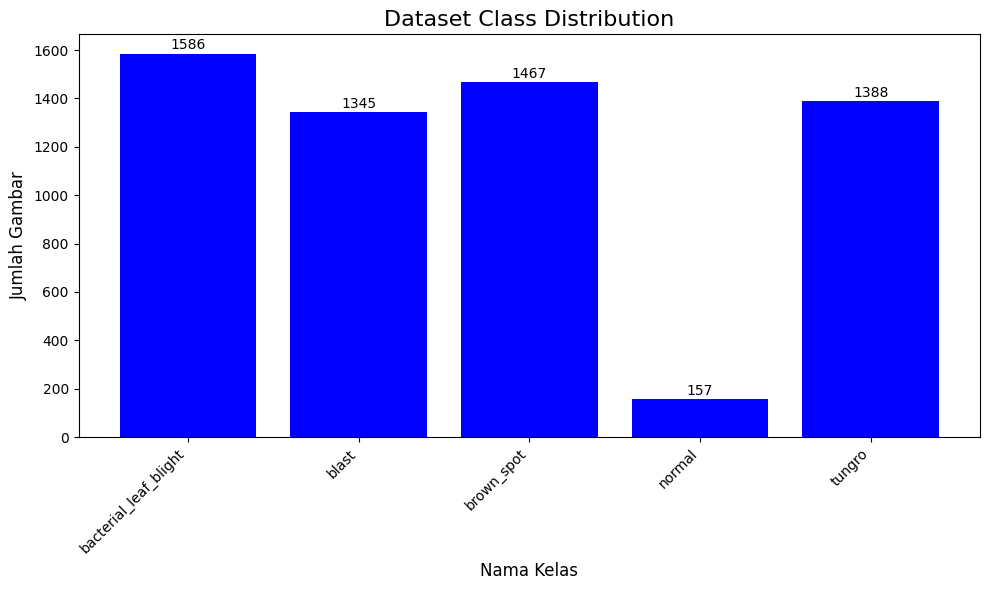

In [6]:
# extra_dataset1, extra_labels1 = load_images_from_directory('datasets/paddy-disease-classification/train_images', 1088)
extra_dataset1, extra_labels1 = load_images_from_directory('datasets/leaf-rice-disease-indonesia', 80)
extra_dataset2, extra_labels2 = load_images_from_directory('datasets/rice_leaves_disease', 305)
# extra_dataset3, extra_labels3 = load_images_from_directory('datasets/no_duplicate_healthy', 960)

dataset = np.concatenate((dataset, extra_dataset1), axis=0)
labels = np.concatenate((labels, extra_labels1), axis=0)

dataset = np.concatenate((dataset, extra_dataset2), axis=0)
labels = np.concatenate((labels, extra_labels2), axis=0)

# dataset = np.concatenate((dataset, extra_dataset3), axis=0)
# labels = np.concatenate((labels, extra_labels3), axis=0)
show_class_distribution(labels.tolist(), title="Dataset Class Distribution")

print('extra dataset loaded')
print('dataset shape:', dataset.shape)
print('labels shape:', labels.shape)

In [7]:
# X_train, X_test, y_train, y_test = train_test_split(dataset, labels, train_size=TRAIN_SPLIT_RATIO, random_state=42)
# X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=TEST_SPLIT_RATIO, random_state=42)

In [7]:
def split_dataset_by_class(dataset, labels, num_test_per_class):
    """
    Splits the dataset into training and testing sets with a fixed number
    of test samples per class.

    Args:
        dataset (np.ndarray): The feature data of the entire dataset.
        labels (np.ndarray): The labels of the entire dataset.
        num_test_per_class (int): The fixed number of test samples for each class.

    Returns:
        tuple: A tuple containing X_train, X_test, y_train, y_test.
    """
    print(f"--- Splitting dataset with a fixed test size of {num_test_per_class} per class ---")
    
    # Get unique classes and their indices
    unique_classes = np.unique(labels)
    
    # Initialize lists to store the split data
    X_train_list, X_test_list = [], []
    y_train_list, y_test_list = [], []
    
    # Iterate through each unique class
    for class_label in unique_classes:
        # Find the indices of samples belonging to the current class
        class_indices = np.where(labels == class_label)[0]
        class_dataset = dataset[class_indices]
        class_labels = labels[class_indices]
        
        # Check if the class has enough samples for the test set
        if len(class_dataset) < num_test_per_class:
            print(f"Warning: Class {class_label} has fewer than {num_test_per_class} samples. It will be entirely used for testing.")
            # Use all samples for testing if not enough
            X_test_list.append(class_dataset)
            y_test_list.append(class_labels)
            
        else:
            # Perform a stratified split for the current class
            X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
                class_dataset,
                class_labels,
                test_size=num_test_per_class,
                random_state=42,
                stratify=class_labels
            )
            
            # Append the results to the lists
            X_train_list.append(X_train_class)
            X_test_list.append(X_test_class)
            y_train_list.append(y_train_class)
            y_test_list.append(y_test_class)
    
    # Concatenate the split data from all classes
    X_train = np.concatenate(X_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)
    
    return X_train, X_test, y_train, y_test

In [8]:
X_train, X_test, y_train, y_test = split_dataset_by_class(dataset, labels, num_test_per_class=50)

--- Splitting dataset with a fixed test size of 50 per class ---


In [9]:
# Save test data from splitted dataset
def save_test_data(X, y, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    for i, (image, label) in enumerate(zip(X, y)):
        if not os.path.exists(f"{output_dir}/{label}"):
            os.makedirs(f"{output_dir}/{label}")
        image_path = os.path.join(output_dir, f"{label}/{label}_{i}.jpg")
        cv2.imwrite(image_path, image)
        
save_test_data(X_test, y_test, 'datasets/result/test_images')

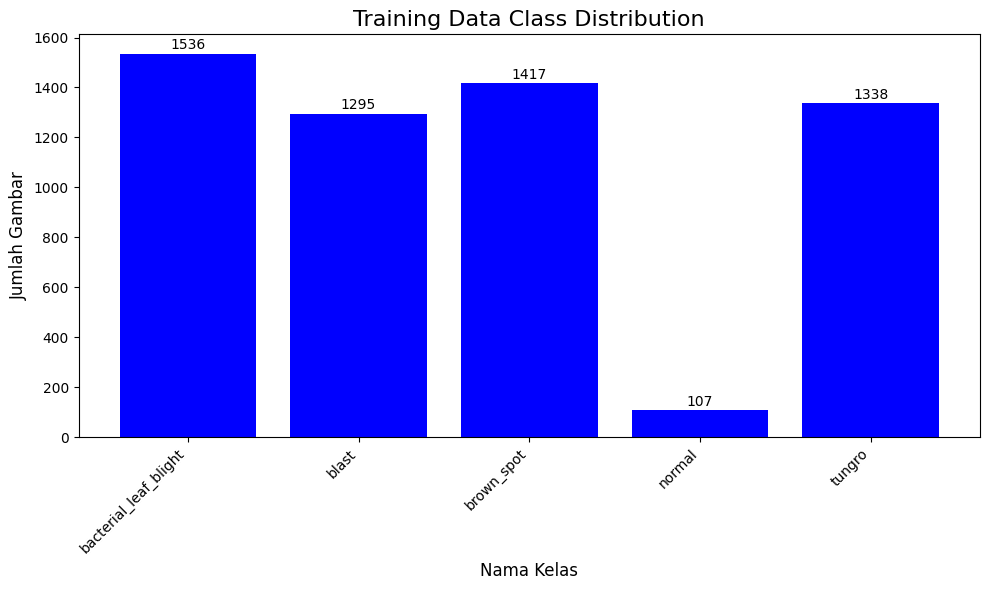

In [11]:
show_class_distribution(y_train.tolist(), title="Training Data Class Distribution")

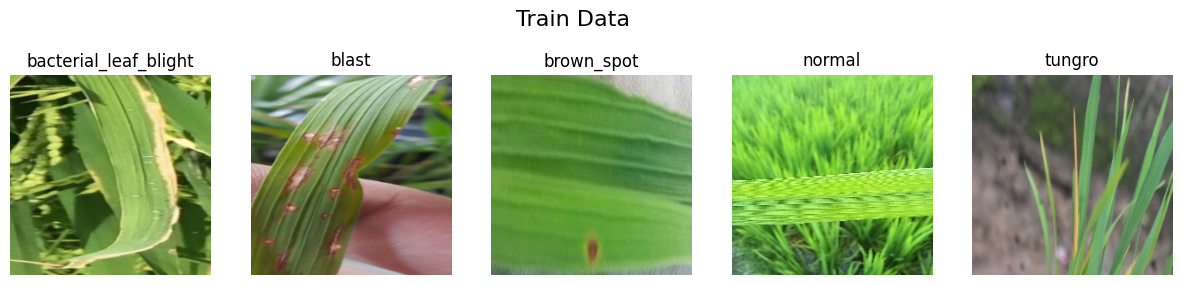

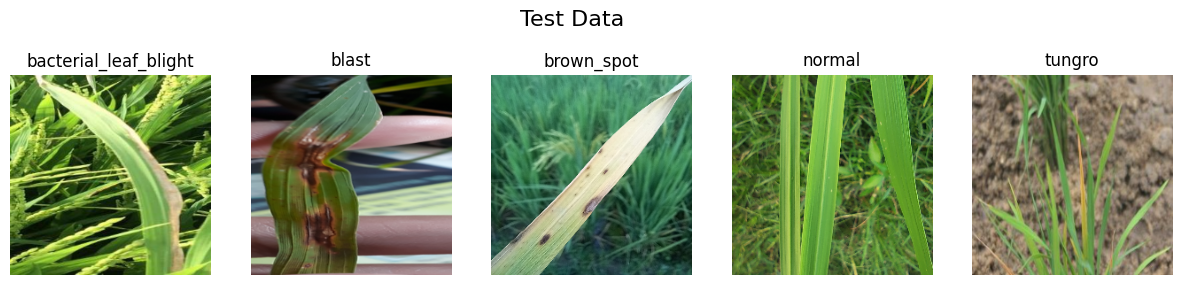

In [10]:
fig = plt.figure(figsize=(15, 6))

fig.suptitle('Train Data', fontsize=16)

if len(LABELS) < 5: cols = len(LABELS)
else: cols = 5

row = (len(LABELS) // 5)+1

for j in range(len(LABELS)):
    fig.add_subplot(row, cols, j+1)
    index = np.where(y_train == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_train[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])


fig = plt.figure(figsize=(15, 6))

fig.suptitle('Test Data', fontsize=16)

for j in range(len(LABELS)):
    fig.add_subplot(row, cols, j+1)
    index = np.where(y_test == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_test[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])
    
# fig = plt.figure(figsize=(15, 6))

# fig.suptitle('Validation Data', fontsize=16)

# for j in range(len(LABELS)):
#     fig.add_subplot(row, cols, j+1)
#     index = np.where(y_val == LABELS[j])[0][0]
#     plt.imshow(cv2.cvtColor(X_val[index], cv2.COLOR_BGR2RGB))
#     plt.axis('off') 
#     plt.title(LABELS[j])

In [11]:
# Fungsi untuk membuat dan menyimpan model ekstraktor fitur
def create_and_save_mobilenet_feature_extractor(model_path):
    """
    Membuat model ekstraktor fitur dari MobileNetV2,
    lalu menyimpannya ke file .h5.
    
    Args:
        model_path (str): Path untuk menyimpan model ekstraktor fitur.

    Returns:
        tf.keras.Model: Model ekstraktor fitur yang sudah dimodifikasi.
    """
    # 1. Muat MobileNetV2 yang sudah terlatih pada ImageNet.
    #    'include_top=False' adalah kunci di sini. Ini akan memuat seluruh
    #    model MobileNetV2 TANPA lapisan klasifikasi terakhirnya (lapisan Dense).
    base_model = MobileNetV2(weights='imagenet',
                             include_top=False,
                             input_shape=INPUT_SHAPE)
    
    base_model.trainable = False
    # x = base_model.get_layer('block_15_expand').output
    output_vector = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    
    feature_extractor_model = Model(inputs=base_model.input, outputs=output_vector)
    
    # 5. Simpan model ekstraktor fitur
    feature_extractor_model.save(model_path)
    
    print("Model ekstraktor fitur dari MobileNetV2 berhasil dibuat dan disimpan di {}".format(model_path))
    print("Jumlah fitur yang dihasilkan: {}".format(base_model.output.shape[1]))
    
    return feature_extractor_model

In [12]:
# Fungsi untuk melatih dan menyimpan model SVM
def train_and_save_svm(features, labels, scaler_path, svm_model_path):
    """
    Melatih StandardScaler dan model SVM menggunakan vektor fitur yang diberikan.
    Scaler dan model SVM kemudian disimpan ke file.

    Args:
        features (np.ndarray): Vektor fitur dari data training.
        labels (np.ndarray): Label dari data training.
        scaler_path (str): Path untuk menyimpan scaler.
        svm_model_path (str): Path untuk menyimpan model SVM.
    """
    print("\nMemulai pelatihan StandardScaler dan SVM...")
    
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': [1e-3, 1e-2, 0.1, 1],
        'kernel': ['rbf']
    }
    grid_svm = GridSearchCV(SVC(), param_grid, cv=5)
    
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    
    fold_accuracies = []
    best_accuracy = 0
    best_svm_model = None
    best_scaler = None
    
    for fold, (train_index, val_index) in enumerate(skf.split(features, labels)):
        print(f"\n--- Fold {fold + 1}/{N_SPLITS} ---")
        
        # Split data for the current fold
        x_train, x_val = features[train_index], features[val_index]
        y_train, y_val = labels[train_index], labels[val_index]
        
        # Train a new scaler for each fold
        scaler = StandardScaler()
        scaled_x_train = scaler.fit_transform(x_train)
        
        # Train a new SVM model for each fold
        # grid_svm.fit(scaled_x_train, y_train)
        svm_model = SVC(kernel='rbf', C=100, gamma=0.001)
        svm_model.fit(scaled_x_train, y_train)

        # print("Best params:", grid_svm.best_params_)
        # print("Best score:", grid_svm.best_score_)
        
        # Evaluate the model
        scaled_x_val = scaler.transform(x_val)
        # y_pred = grid_svm.best_estimator_.predict(scaled_x_val)
        y_pred = svm_model.predict(scaled_x_val)
        accuracy = accuracy_score(y_val, y_pred)
        
        print(f"Accuracy for Fold {fold + 1}: {accuracy:.4f}")
        fold_accuracies.append(accuracy)
        
        # Save the model and scaler if it's the best so far
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            # best_svm_model = grid_svm.best_estimator_
            best_svm_model = svm_model
            best_scaler = scaler
            
    print("\n--- K-Fold Cross-Validation Summary ---")
    print(f"Accuracy per fold: {fold_accuracies}")
    print(f"Average Accuracy: {np.mean(fold_accuracies):.4f} +/- {np.std(fold_accuracies):.4f}")
    
    # Save the best model and scaler
    if best_svm_model is not None:
        # Simpan scaler yang sudah dilatih
        with open(scaler_path, 'wb') as f:
            pickle.dump(best_scaler, f)
        # Simpan model SVM yang sudah dilatih
        with open(svm_model_path, 'wb') as f:
            pickle.dump(best_svm_model, f)
        print(f"\nBest model and scaler saved based on validation accuracy of {best_accuracy:.4f}.")
    else:
        print("\nCould not save the best model. Check for errors.")

In [13]:
# Fungsi untuk memuat model dan melakukan prediksi pada gambar baru
def load_and_predict(image_path, extractor_path, scaler_path, svm_model_path, class_names):
    """
    Memuat model yang sudah disimpan dan melakukan prediksi pada satu gambar baru.

    Args:
        image_path (str): Path ke gambar baru yang akan diprediksi.
        extractor_path (str): Path ke model ekstraktor fitur .h5.
        scaler_path (str): Path ke scaler .pkl.
        svm_model_path (str): Path ke model SVM .pkl.
        class_names (list): Daftar nama kelas.
    """
    print("\n--- Memulai Prediksi pada Gambar Baru ---")

    # Muat model ekstraktor fitur
    feature_extractor = tf.keras.models.load_model(extractor_path, compile=False)
    print("Model ekstraktor fitur berhasil dimuat.")
    
    # Muat scaler
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    print("Scaler berhasil dimuat.")
    
    # Muat model SVM
    with open(svm_model_path, 'rb') as f:
        svm_model = pickle.load(f)
    print("Model SVM berhasil dimuat.")

    # Pre-processing gambar baru
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Gambar tidak ditemukan. Silakan cek path.")
        return
        
    img_resized = cv2.resize(img, IMG_SIZE)
    img_processed = np.expand_dims(img_resized, axis=0)
    # img_processed = tf.keras.applications.mobilenet_v2.preprocess_input(img_processed)
    
    print("Gambar berhasil dipre-proses.")

    # Ekstraksi fitur
    features = feature_extractor.predict(img_processed)
    
    # Scaling fitur
    scaled_features = scaler.transform(features)
    
    # Prediksi
    prediction = svm_model.predict(scaled_features)
    # predicted_class_index = int()
    predicted_class_name = prediction[0]
    
    # Tampilkan hasil
    print("\nHasil Prediksi:")
    print("Kelas yang diprediksi: {}".format(predicted_class_name))

In [14]:
# --- BAGIAN 1: PEMBUATAN DAN PELATIHAN ---
# Langkah 1: Buat dan simpan model ekstraktor fitur
feature_extractor = create_and_save_mobilenet_feature_extractor(EXTRACTOR_PATH)

C:\Users\RYZEN 5\AppData\Local\Temp\ipykernel_7372\2000649192.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet',


Model ekstraktor fitur dari MobileNetV2 berhasil dibuat dan disimpan di Results/250826 2156 Mixed On Field No Duplicate Normal Indo\mobilenet_feature_extractor.h5
Jumlah fitur yang dihasilkan: 8


In [ ]:
# feature_extractor = tf.keras.models.load_model(EXTRACTOR_PATH, compile=False)
# feature_extractor.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 227, 227,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 114, 114,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 114, 114,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 114, 114,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 114, 114,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 114, 114,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 114, 114,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 114, 114,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 114, 114,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 114, 114,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 114, 114,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 114, 114,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 115, 115,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 57, 57,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 57, 57,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 57, 57,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 57, 57,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# Langkah 2: Simulasi ekstraksi fitur dari data training (misalnya, 100 gambar)
# Anda akan mengganti ini dengan loop yang sebenarnya untuk dataset Anda

train_features = feature_extractor.predict(X_train)
test_features = feature_extractor.predict(X_test)
int_y_train = (np.array([np.where(LABELS == label)[0][0] for label in y_train]))

178/178 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step


In [16]:
train_features.shape

(5693, 1280)

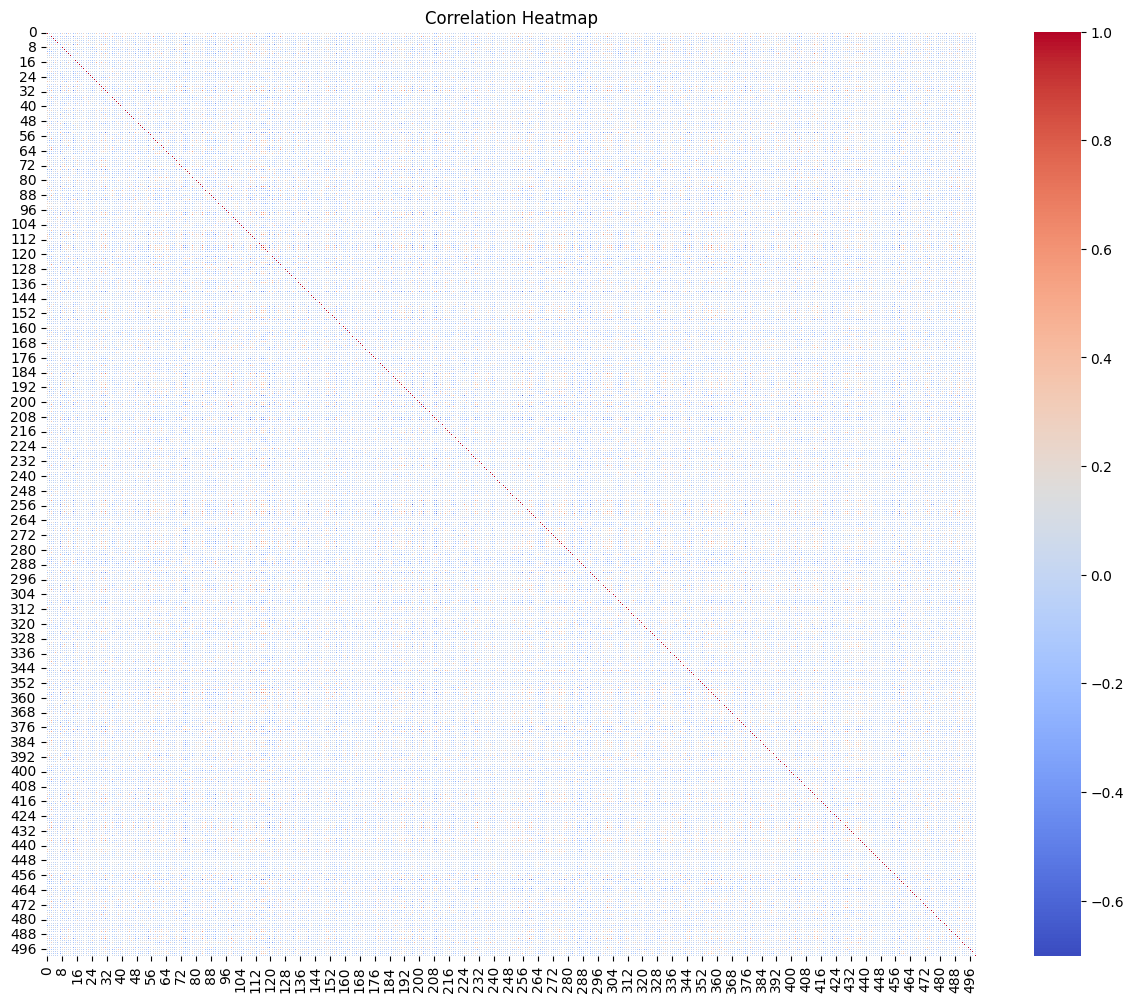

In [19]:
scaler = StandardScaler()
x_train_normal = scaler.fit_transform(train_features)
pd_x_anomali = pd.DataFrame(x_train_normal[:,:500])
plt.figure(figsize=(15, 12)) # Adjust figure size as needed
sns.heatmap(pd_x_anomali.corr(), cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

In [20]:
# Langkah 3: Latih dan simpan SVM
train_and_save_svm(train_features, y_train, SCALER_PATH, SVM_MODEL_PATH)


Memulai pelatihan StandardScaler dan SVM...

--- Fold 1/5 ---
Accuracy for Fold 1: 0.9219

--- Fold 2/5 ---
Accuracy for Fold 2: 0.9315

--- Fold 3/5 ---
Accuracy for Fold 3: 0.9385

--- Fold 4/5 ---
Accuracy for Fold 4: 0.9279

--- Fold 5/5 ---
Accuracy for Fold 5: 0.9130

--- K-Fold Cross-Validation Summary ---
Accuracy per fold: [0.9218612818261633, 0.9315188762071993, 0.9385425812115891, 0.9279437609841827, 0.9130052724077329]
Average Accuracy: 0.9266 +/- 0.0087

Best model and scaler saved based on validation accuracy of 0.9385.


Model ekstraktor fitur berhasil dimuat.
Scaler berhasil dimuat.
Model SVM berhasil dimuat.
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.96      0.94      0.95        50
                blast       0.82      0.98      0.89        50
           brown_spot       0.84      0.98      0.91        50
               normal       0.97      0.64      0.77        50
               tungro       0.92      0.92      0.92        50

             accuracy                           0.89       250
            macro avg       0.90      0.89      0.89       250
         weighted avg       0.90      0.89      0.89       250

Confusion Matrix for SVM:


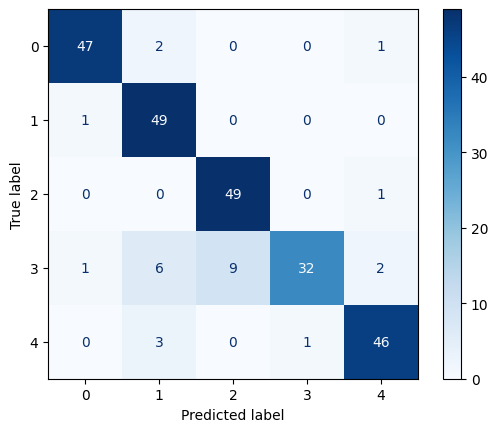

In [21]:
# Muat model ekstraktor fitur
feature_extractor = tf.keras.models.load_model(EXTRACTOR_PATH, compile=False)
print("Model ekstraktor fitur berhasil dimuat.")

# Muat scaler
with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)
print("Scaler berhasil dimuat.")

# Muat model SVM
with open(SVM_MODEL_PATH, 'rb') as f:
    svm_model = pickle.load(f)
print("Model SVM berhasil dimuat.")

x_test_normal = scaler.transform(test_features)

y_pred = svm_model.predict(x_test_normal)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix for SVM:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
print("="*50)

['bacterial_leaf_blight' 'blast' 'brown_spot' 'normal' 'tungro'] ['red', 'green', 'blue', 'yellow', 'gray']


C:\Users\RYZEN 5\AppData\Local\Temp\ipykernel_2136\1402748680.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_color, cmap='viridis', alpha=0.8)


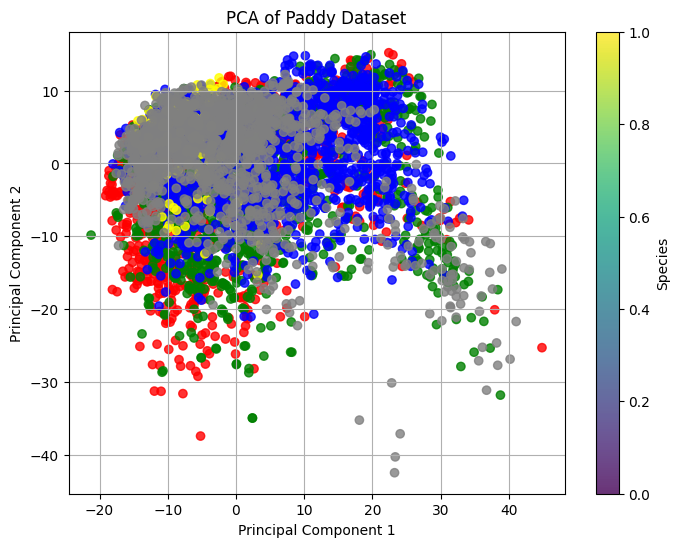

In [22]:
x_train_normal = scaler.transform(train_features)
my_pca = PCA(n_components=2)
X_pca = my_pca.fit_transform(x_train_normal)

colors = ['red', 'green', 'blue', 'yellow', 'gray']

print(LABELS, colors)

y_color = [colors[np.where(LABELS == label)[0][0]] for label in y_train]

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_color, cmap='viridis', alpha=0.8)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Paddy Dataset')
plt.colorbar(label='Species')
plt.grid(True)
plt.show()

In [23]:
# --- BAGIAN 2: PENGUJIAN IMPLEMENTASI ---
# Langkah 4: Simulasi proses di perangkat mobile
# test_image_path = f"E:/Backup Mario/Coding Room/Rice_Disease/datasets/result/test_images/bacterial_leaf_blight/bacterial_leaf_blight_196.jpg"
# test_image_path = f"C:/Users/RYZEN 5/Downloads/rice_blast_1.webp"
test_image_path = f"C:/Users/RYZEN 5/Downloads/brown-spot-fungal-disease-infects-coleoptile-leaves-leaf-sheath-panicle-branches-glumes-spikelets-rice-212252217.webp"
# test_image_path = f"C:/Users/RYZEN 5/Downloads/brown-spot-fungal-disease-that-600nw-1611333022.webp"

# Lakukan prediksi menggunakan model yang sudah disimpan
load_and_predict(test_image_path, EXTRACTOR_PATH, SCALER_PATH, SVM_MODEL_PATH, LABELS)


--- Memulai Prediksi pada Gambar Baru ---
Model ekstraktor fitur berhasil dimuat.
Scaler berhasil dimuat.
Model SVM berhasil dimuat.
Gambar berhasil dipre-proses.
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Hasil Prediksi:
Kelas yang diprediksi: blast
